In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
#For persistance
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

In [2]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.7
)

In [3]:
result = llm.invoke("Who is the president of the United States?")
print(result)

content='As of now, the President of the United States is **Joe\u202fBiden**.' additional_kwargs={'reasoning_content': 'The user asks: "Who is the president of the United States?" This is a factual question. We need to respond with the current president. As of the last known data cutoff, it\'s 2024-06, but the current president is Joe Biden (in office 2021-2025). However, it\'s 2026 now? The user might be expecting the current president as of 2026? The last election was in 2024, so likely the president is still Joe Biden if reelected. But we don\'t have data after 2024. The question likely expects Joe Biden. The user might want a simple answer: Joe Biden. Or "As of now, the president is Joe Biden." We can also note that the president is Joe Biden.\n\nWe should answer directly.'} response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_tokens': 80, 'total_tokens': 268, 'completion_time': 0.237262202, 'completion_tokens_details': {'reasoning_tokens': 161}, 'prompt_time': 0.00

In [6]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] #Reducer

In [7]:
def chat_node(state: ChatState):
    messages = state["messages"]
#send to llm
    response = llm.invoke(messages)
    return {"messages" : [response]}


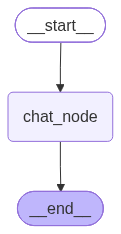

In [8]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpoint)
chatbot

In [66]:
# Fot each thread, we can maintain a separate state. Here, we will simulate two threads of conversation with the chatbot.
thread_id = 1
initial_state = {
    "messages": [HumanMessage(content="What is Agentic AI?")]
}
config = {"configurable": {"thread_id": thread_id}}
response = chatbot.invoke(initial_state, config=config)

In [ ]:
#Provides information about all the threads and their states. This is useful for debugging and understanding the current state of the chatbot.
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='2b786162-5193-462a-b209-423a0d5fe422'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to a simple greeting. Probably just a friendly reply.'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 72, 'total_tokens': 106, 'completion_time': 0.035257259, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.003450253, 'prompt_tokens_details': None, 'queue_time': 0.211383186, 'total_time': 0.038707512}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b8e9-5d65-7033-8804-a8a857b81946-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 34, 'total_tokens': 106, 'output_token_details': {'reasoni

In [ ]:
response['messages'][-1].content

'## Agentic AI – A Quick Overview\n\n**Agentic AI** refers to artificial intelligence systems that are endowed with *agency*: the capacity to set goals, make decisions, take actions, and pursue those goals autonomously—often in dynamic, real‑world environments. In short, it’s AI that behaves like an *agent* in the sense of the classic “intelligent agent” paradigm in computer science and cognitive science.\n\n---\n\n### 1. Core Characteristics\n\n| Feature | What it means for Agentic AI |\n|---------|------------------------------|\n| **Autonomy** | The system can operate without continuous human instruction. |\n| **Goal‑orientation** | It has a defined objective (or set of objectives) that it seeks to achieve. |\n| **Decision‑making** | It evaluates alternatives, predicts outcomes, and chooses actions. |\n| **Learning & adaptation** | It refines its behavior based on experience or feedback. |\n| **Environment interaction** | It senses, perceives, and affects its surroundings. |\n| **Se

##### No Persistant Chat - Only One Session

In [9]:
thread_id = 1
config = {"configurable": {"thread_id": thread_id}}
while True:
    user_input = input("User: ")
    print('User:', user_input)
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chatbot. Goodbye!")
        break
    response = chatbot.invoke({'messages':[HumanMessage(content=user_input)]}, config=config)
    print('Chatbot:',response['messages'][-1].content)

User: Hi
Chatbot: Hello! How can I help you today?
User: exit
Exiting the chatbot. Goodbye!


### Persistance